In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use("bmh")

def call_option_price(S, E, rf, sigma, T, t=0):
    # 1st calculate d1 and d2 parameters
    d1 = (np.log(S/E) + (rf + (sigma**2)/2)*(T-t)) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma * np.sqrt(T - t)
    print("The d1 & d2 parameters: (%s, %s)" % (d1, d2))
    # use the N(x) to calculate the price of the option
    return S*stats.norm.cdf(d1) - E*np.exp(-rf*(T-t))*stats.norm.cdf(d2)

def put_option_price(S, E, rf, sigma, T, t=0):
    # 1st calculate d1 and d2 parameters
    d1 = (np.log(S/E) + (rf + (sigma**2)/2)*(T-t)) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma * np.sqrt(T - t)
    print("The d1 & d2 parameters: (%s, %s)" % (d1, d2))
    # use the N(x) to calculate the price of the option
    return E*np.exp(-rf*(T-t))*stats.norm.cdf(-d2) - S*stats.norm.cdf(-d1)

if __name__=='__main__':
    # underlying stock price at t=0
    S0 = 100
    # strike price
    E = 100
    # Expiry 1 yr = 365 days
    T = 1
    # risk-free rate 
    rf = 0.05
    # volatility of the underlying stocks
    sigma = 0.2
    
    print("Call option price according to Black Scholes model: ", call_option_price(S0, E, rf, sigma, T))
    print("Put option price according to Black Scholes model: ", put_option_price(S0, E, rf, sigma, T))

The d1 & d2 parameters: (0.35000000000000003, 0.15000000000000002)
Call option price according to Black Scholes model:  10.450583572185565
The d1 & d2 parameters: (0.35000000000000003, 0.15000000000000002)
Put option price according to Black Scholes model:  5.573526022256971


The d1 & d2 parameters: (0.350000, 0.150000)
The d1 & d2 parameters: (0.350000, 0.150000)

Black-Scholes Option Pricing Results:
Stock Price: 100.0
Strike Price: 100.0
Risk-free Rate: 0.05
Volatility: 0.2
Time to Maturity: 1.0 years
Call Option Price: 10.4506
Put Option Price: 5.5735


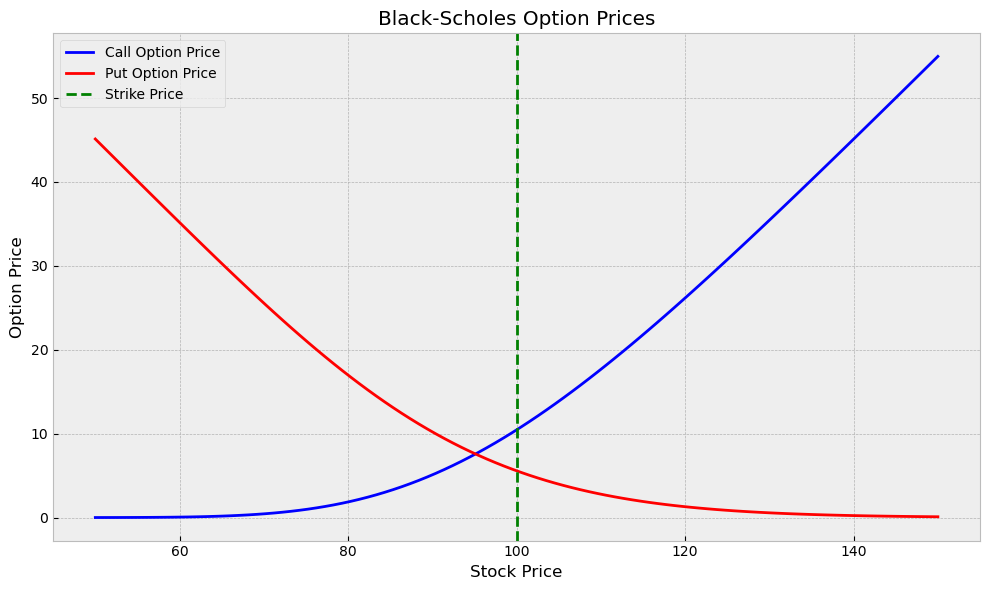

In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Black-Scholes Option Pricing Model
Author: Sandy Herho
License: WTFPL - Do What The F*** You Want To Public License
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys
import argparse

def setup_style(style="bmh"):
    """Set the plotting style."""
    try:
        plt.style.use(style)
    except:
        print(f"Style {style} not found. Using default style.")
        plt.style.use("default")

def call_option_price(S, E, rf, sigma, T, t=0, verbose=True):
    """
    Calculate the call option price using the Black-Scholes model.
    
    Parameters:
    -----------
    S : float
        Current stock price
    E : float
        Strike price
    rf : float
        Risk-free rate (annual)
    sigma : float
        Volatility of the underlying stock (annual)
    T : float
        Time to maturity (in years)
    t : float, optional
        Current time, default is 0
    verbose : bool, optional
        Whether to print intermediate calculations
        
    Returns:
    --------
    float
        Call option price
    """
    # Calculate time to maturity
    tau = T - t
    
    # Calculate d1 and d2 parameters
    d1 = (np.log(S/E) + (rf + (sigma**2)/2)*tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    if verbose:
        print(f"The d1 & d2 parameters: ({d1:.6f}, {d2:.6f})")
    
    # Calculate call option price
    return S*stats.norm.cdf(d1) - E*np.exp(-rf*tau)*stats.norm.cdf(d2)

def put_option_price(S, E, rf, sigma, T, t=0, verbose=True):
    """
    Calculate the put option price using the Black-Scholes model.
    
    Parameters:
    -----------
    S : float
        Current stock price
    E : float
        Strike price
    rf : float
        Risk-free rate (annual)
    sigma : float
        Volatility of the underlying stock (annual)
    T : float
        Time to maturity (in years)
    t : float, optional
        Current time, default is 0
    verbose : bool, optional
        Whether to print intermediate calculations
        
    Returns:
    --------
    float
        Put option price
    """
    # Calculate time to maturity
    tau = T - t
    
    # Calculate d1 and d2 parameters
    d1 = (np.log(S/E) + (rf + (sigma**2)/2)*tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    if verbose:
        print(f"The d1 & d2 parameters: ({d1:.6f}, {d2:.6f})")
    
    # Calculate put option price
    return E*np.exp(-rf*tau)*stats.norm.cdf(-d2) - S*stats.norm.cdf(-d1)

def plot_option_prices(S_range, E, rf, sigma, T, t=0):
    """
    Plot call and put option prices for a range of stock prices.
    
    Parameters:
    -----------
    S_range : array-like
        Range of stock prices to plot
    E : float
        Strike price
    rf : float
        Risk-free rate (annual)
    sigma : float
        Volatility of the underlying stock (annual)
    T : float
        Time to maturity (in years)
    t : float, optional
        Current time, default is 0
    """
    call_prices = [call_option_price(S, E, rf, sigma, T, t, verbose=False) for S in S_range]
    put_prices = [put_option_price(S, E, rf, sigma, T, t, verbose=False) for S in S_range]
    
    plt.figure(figsize=(10, 6))
    plt.plot(S_range, call_prices, 'b-', label='Call Option Price')
    plt.plot(S_range, put_prices, 'r-', label='Put Option Price')
    plt.axvline(x=E, color='g', linestyle='--', label='Strike Price')
    plt.grid(True)
    plt.xlabel('Stock Price')
    plt.ylabel('Option Price')
    plt.title('Black-Scholes Option Prices')
    plt.legend()
    plt.tight_layout()
    plt.show()

def parse_args_or_use_defaults():
    """Parse command line arguments or use defaults if in interactive environment."""
    # Check if we're in a Jupyter notebook or IPython environment
    is_notebook = 'ipykernel' in sys.modules
    
    if is_notebook or len(sys.argv) <= 1:
        # Use default values in notebook environment
        class Args:
            pass
        
        args = Args()
        args.stock_price = 100.0
        args.strike_price = 100.0
        args.risk_free_rate = 0.05
        args.volatility = 0.2
        args.time_to_maturity = 1.0
        args.plot = True
        args.style = 'bmh'
        
        return args
    else:
        # Parse command line arguments
        parser = argparse.ArgumentParser(description='Black-Scholes Option Pricing Model')
        
        parser.add_argument('--stock_price', '-s', type=float, default=100.0,
                            help='Current stock price (default: 100.0)')
        parser.add_argument('--strike_price', '-e', type=float, default=100.0,
                            help='Strike price (default: 100.0)')
        parser.add_argument('--risk_free_rate', '-r', type=float, default=0.05,
                            help='Risk-free interest rate (default: 0.05)')
        parser.add_argument('--volatility', '-v', type=float, default=0.2,
                            help='Volatility of the underlying stock (default: 0.2)')
        parser.add_argument('--time_to_maturity', '-t', type=float, default=1.0,
                            help='Time to maturity in years (default: 1.0)')
        parser.add_argument('--plot', '-p', action='store_true',
                            help='Plot option prices for a range of stock prices')
        parser.add_argument('--style', type=str, default='bmh',
                            help='Matplotlib style to use for plotting (default: bmh)')
        
        return parser.parse_args()

def black_scholes_calculator(stock_price=100.0, strike_price=100.0, risk_free_rate=0.05, 
                            volatility=0.2, time_to_maturity=1.0, plot=False, style='bmh'):
    """
    Calculate option prices using specified parameters and optionally plot results.
    
    This function is designed to be called directly from a notebook or script.
    """
    # Set up plotting style
    setup_style(style)
    
    # Calculate option prices
    call_price = call_option_price(stock_price, strike_price, risk_free_rate, 
                                   volatility, time_to_maturity)
    
    put_price = put_option_price(stock_price, strike_price, risk_free_rate, 
                                 volatility, time_to_maturity)
    
    print("\nBlack-Scholes Option Pricing Results:")
    print(f"Stock Price: {stock_price}")
    print(f"Strike Price: {strike_price}")
    print(f"Risk-free Rate: {risk_free_rate}")
    print(f"Volatility: {volatility}")
    print(f"Time to Maturity: {time_to_maturity} years")
    print(f"Call Option Price: {call_price:.4f}")
    print(f"Put Option Price: {put_price:.4f}")
    
    # Plot option prices if requested
    if plot:
        # Create a range of stock prices from 50% to 150% of the strike price
        S_range = np.linspace(strike_price * 0.5, strike_price * 1.5, 100)
        plot_option_prices(S_range, strike_price, risk_free_rate, 
                           volatility, time_to_maturity)
    
    return {'call_price': call_price, 'put_price': put_price}

def main():
    """Main function to handle command line arguments and run the program."""
    args = parse_args_or_use_defaults()
    
    return black_scholes_calculator(
        stock_price=args.stock_price,
        strike_price=args.strike_price,
        risk_free_rate=args.risk_free_rate,
        volatility=args.volatility,
        time_to_maturity=args.time_to_maturity,
        plot=args.plot,
        style=args.style
    )

if __name__ == '__main__':
    main()